In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import keras
from keras.models import Sequential
from keras.layers import Dense

In [3]:
# 1. ساخت داده مصنوعی با تابع درجه 2 و نویز
np.random.seed(42)
n_samples = 200
X = np.random.uniform(-3, 3, n_samples)
y = 2 * X**2 + 3 * X + 5 + np.random.normal(0, 2, n_samples)  # تابع درجه 2 + نویز

# نمایش 10 نمونه اول
print("10 نمونه اول داده:")
for i in range(10):
    print(f"X = {X[i]:.3f}, y = {y[i]:.3f}")

10 نمونه اول داده:
X = -0.753, y = 2.515
X = 2.704, y = 28.204
X = 1.392, y = 13.637
X = 0.592, y = 6.048
X = -2.064, y = 11.059
X = -2.064, y = 8.276
X = -2.651, y = 8.724
X = 2.197, y = 22.558
X = 0.607, y = 5.607
X = 1.248, y = 13.437


In [8]:
X.shape

(200,)

In [4]:
# 2. تقسیم داده به آموزش و تست
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# تغییر شکل داده‌ها برای ورود به Keras (تبدیل به ستون)
X_train = X_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)

In [5]:
# 3. ساخت مدل رگرسیون با Keras 3
model = Sequential([
    Dense(16, activation='relu', input_shape=(1,)),
    Dense(16, activation='relu'),
    Dense(1)  # لایه خروجی برای رگرسیون
])

model.summary()

D:\Shahed\AI Intro\a\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │              32 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# کامپایل مدل
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [9]:
# 4. آموزش مدل
print("\nدر حال آموزش مدل...")
history = model.fit(X_train, y_train, 
                    epochs=50, 
                    batch_size=32, 
                    validation_split=0.2)  


در حال آموزش مدل...
Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 182.4331 - mae: 11.0987 - val_loss: 164.4638 - val_mae: 10.9286
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 181.4362 - mae: 11.0553 - val_loss: 163.5438 - val_mae: 10.8888
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 180.4283 - mae: 11.0147 - val_loss: 162.5977 - val_mae: 10.8475
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 179.4016 - mae: 10.9710 - val_loss: 161.6120 - val_mae: 10.8047
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 178.2885 - mae: 10.9260 - val_loss: 160.5988 - val_mae: 10.7605
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 177.1643 - mae: 10.8792 - val_loss: 159.5395 - val_mae: 10.7142
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 176.0092 - mae: 10.8312 - val_loss: 158.4145 - val_mae: 10.6650
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 174.7521 - mae: 10.7788 - val_loss: 157.2121 - val_mae: 10.6124
Epoch 9/50


In [10]:
# 5. پیش‌بینی
y_train_pred = model.predict(X_train, verbose=0)
y_test_pred = model.predict(X_test, verbose=0)

In [13]:
# 6. محاسبه معیارهای ارزیابی با scikit-learn
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\n" + "="*50)
print("معیارهای ارزیابی مدل:")
print("="*50)
print("\nمجموعه آموزش:")
print(f"MSE : {train_mse:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"MAE : {train_mae:.4f}")
print(f"R²  : {train_r2:.4f}")

print("\nمجموعه تست:")
print(f"MSE : {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE : {test_mae:.4f}")
print(f"R²  : {test_r2:.4f}")


معیارهای ارزیابی مدل:

مجموعه آموزش:
MSE : 43.8061
RMSE: 6.6186
MAE : 4.7651
R²  : 0.2608

مجموعه تست:
MSE : 40.7625
RMSE: 6.3846
MAE : 4.5407
R²  : 0.2685


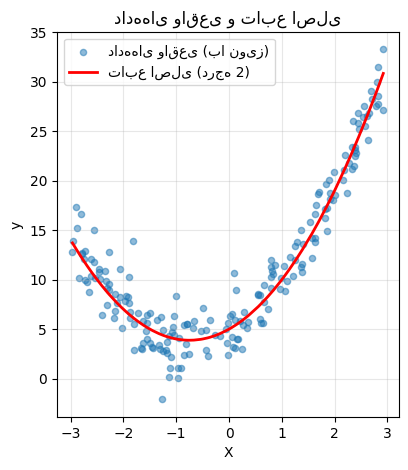

In [14]:
plt.figure(figsize=(15, 5))
# نمودار 1: داده های اصلی و پیش‌بینی مدل
plt.subplot(1, 3, 1)
X_sorted = np.sort(X)
y_sorted = 2 * X_sorted**2 + 3 * X_sorted + 5  # تابع اصلی بدون نویز
plt.scatter(X, y, alpha=0.5, label='داده‌های واقعی (با نویز)', s=20)
plt.plot(X_sorted, y_sorted, 'r-', label='تابع اصلی (درجه 2)', linewidth=2)
plt.xlabel('X')
plt.ylabel('y')
plt.title('داده‌های واقعی و تابع اصلی')
plt.legend()
plt.grid(True, alpha=0.3)

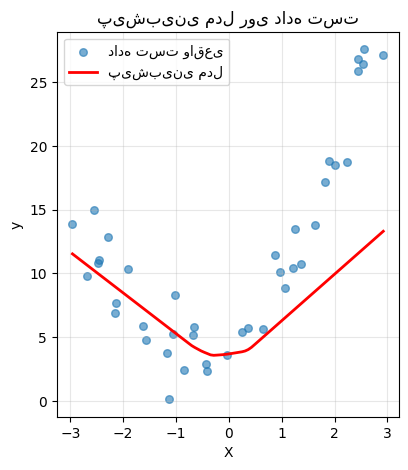

In [16]:
# نمودار 2: پیش‌بینی مدل روی داده تست
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 2)
plt.scatter(X_test, y_test, alpha=0.6, label='داده تست واقعی', s=30)
x_range = np.linspace(X_test.min(), X_test.max(), 100).reshape(-1, 1)
y_range_pred = model.predict(x_range, verbose=0)
plt.plot(x_range, y_range_pred, 'r-', label='پیش‌بینی مدل', linewidth=2)
plt.xlabel('X')
plt.ylabel('y')
plt.title('پیش‌بینی مدل روی داده تست')
plt.legend()
plt.grid(True, alpha=0.3)

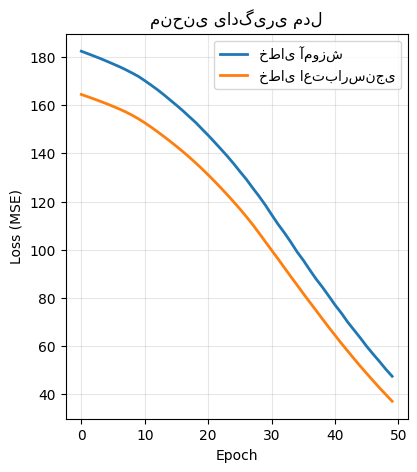

In [18]:
# نمودار 3: خطای آموزش در طول epochs
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 3)
plt.plot(history.history['loss'], label='خطای آموزش', linewidth=2)
plt.plot(history.history['val_loss'], label='خطای اعتبارسنجی', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('منحنی یادگیری مدل')
plt.legend()
plt.grid(True, alpha=0.3)